In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn 
from sklearn import mixture
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

In [3]:
x = np.load("formationchannels.npy")

[[17.12172682]
 [ 5.94121793]
 [ 6.35914124]
 ...
 [34.34170191]
 [30.27018478]
 [25.93264098]]


Text(0.5, 0, 'Black hole mass $[M_\\odot]$')

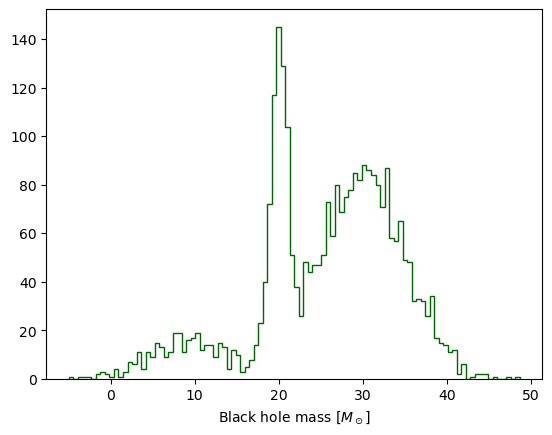

In [5]:
print(x)
plt.hist(x, bins=100, histtype="step", color="darkgreen")
plt.xlabel(r"Black hole mass $[M_\odot]$")

Think I see three mode. From theory I know that there are five possible formation channel: common envelope (CE), chemically omogeneous stars (CHE), globular cluster (GC), nuclear star cluster (NSC) and stable mass transfer (SMT). 

In [10]:
print(x, x.shape) #(N,1) N row and 1 column --> format that sklearn want

[[17.12172682]
 [ 5.94121793]
 [ 6.35914124]
 ...
 [34.34170191]
 [30.27018478]
 [25.93264098]] (2950, 1)


In [12]:
print(x.shape[0])

2950


### Gaussian mixture model 

$p(\mathbf{x_i}|\theta) = \sum_{j=1}^{N} \alpha_j \mathcal{N}(\mathbf{x_i} \vert \boldsymbol{\mu}_j, \boldsymbol{\sigma}_j)$

In [24]:
sklearn.mixture.GaussianMixture(n_components=x.shape[0])
gm = GaussianMixture(n_components= 1).fit(x) #train the model on the data using fit method 

C:\Users\User\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Impossibile trovare il file specificato
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\User\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\User\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\User\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\User\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(ex

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows

AIC: [20945.9726085902, 20753.496007115133, 20082.938230997795, 20101.600433331405, 20112.985983571725, 20120.509776054794, 20129.281958803625, 20132.920330514928, 20132.73813359667, 20134.90637353424]
Lenght AIC: 10


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(


Text(0, 0.5, 'AIC')

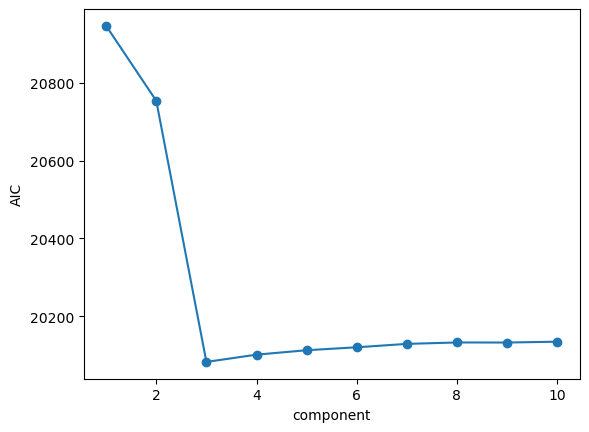

In [26]:
#compute the fit with 10 gaussian and compute the AIC 
total_aic = []
for i in range(1,10+1): 
    gm = GaussianMixture(i).fit(x)
    aic = gm.aic(x) 
    total_aic.append(aic)
    #print(aic)

print("AIC:", total_aic)
print("Lenght AIC:", len(total_aic))
plt.plot(np.arange(1,11), total_aic, marker="o")
plt.xlabel('component')
plt.ylabel('AIC')

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(


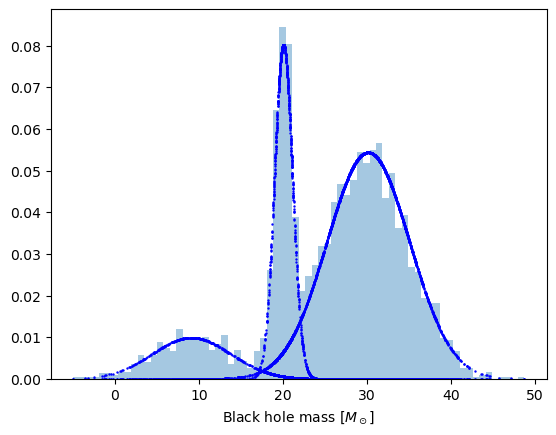

In [38]:
#best model with 3 gaussian  (See AIC)
N = 3

gm = GaussianMixture(n_components= N).fit(x) 

gm_mean = gm.means_
gm_cov = gm.covariances_ 
gm_weight = gm.weights_
gm_sigma = np.sqrt(gm_cov)

plt.hist(x,bins=70, density=True, alpha=0.4)
pdf_total = np.zeros_like(x) 
for mean,sigma,weight in zip(gm_mean, gm_sigma, gm_weight): 
    pdf_gauss = norm.pdf(x, loc=mean, scale=sigma)
    plt.scatter(x, weight*pdf_gauss, s=0.5, color="blue")
    plt.xlabel(r"Black hole mass $[M_\odot]$")
    pdf_total += weight * pdf_gauss 

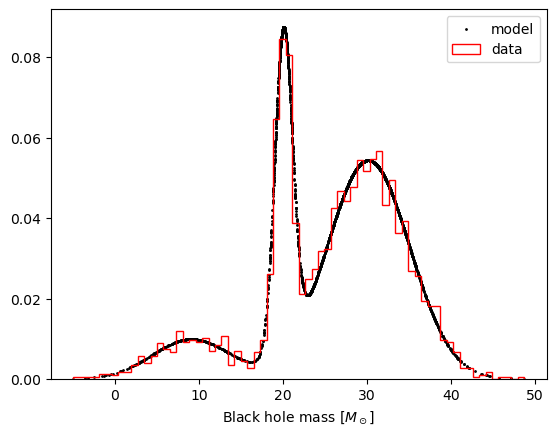

In [42]:
plt.scatter(x,pdf_total, s=1, color="black", label="model")
plt.hist(x,bins=70, density=True, histtype='step', color="red", label="data")
plt.xlabel(r"Black hole mass $[M_\odot]$")
plt.legend()

### class label or responsabilities
probability that a given gravitational wave event comes from a given channel 

In [46]:
log_prob = gm.score_samples(x.reshape(-1,1))
PDF_tot_plot = np.exp(log_prob)
responsibilities = gm.predict_proba(x.reshape(-1,1))

In [56]:
print("responsabilities:", responsibilities)
print(len(responsibilities))
print(len(PDF_tot_plot))

responsabilities: [[3.94563166e-01 2.84679266e-01 3.20757568e-01]
 [9.99962768e-01 3.72317474e-05 9.75049225e-38]
 [9.99946684e-01 5.33161577e-05 1.52440344e-35]
 ...
 [1.17595745e-07 9.99999882e-01 2.19557004e-39]
 [6.21727104e-06 9.99993783e-01 1.71208482e-20]
 [3.92933457e-04 9.99606537e-01 5.29681999e-07]]
2950
2950


Text(0.5, 0, 'responsability')

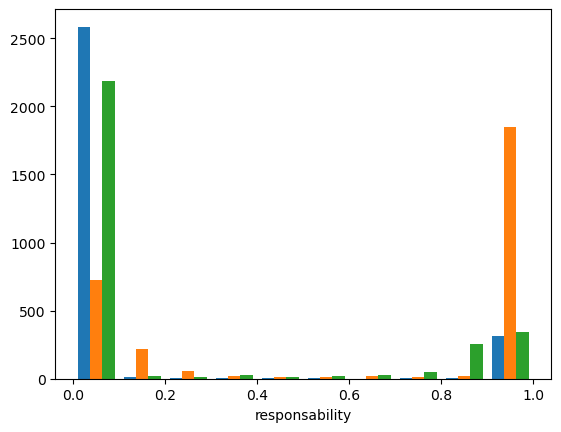

In [50]:
plt.hist(responsibilities, bins=10)
plt.xlabel("responsability")

Text(0, 0.5, 'total PDF')

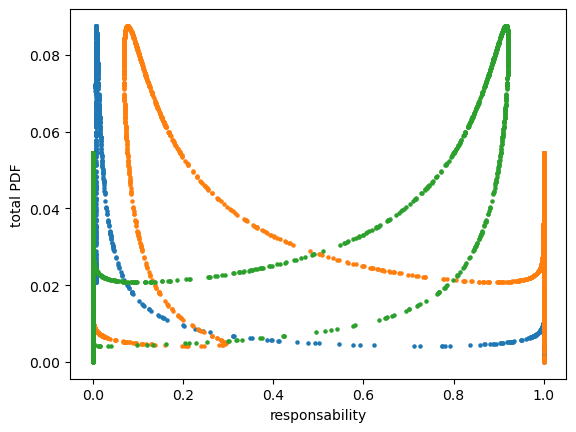

In [52]:
plt.scatter(responsibilities[:,0], PDF_tot_plot, s=5)
plt.scatter(responsibilities[:,1], PDF_tot_plot, s=5)
plt.scatter(responsibilities[:,2], PDF_tot_plot, s=5)
plt.xlabel("responsability")
plt.ylabel("total PDF")

In [60]:
PDF_tot_plot_cluster = responsibilities * PDF_tot_plot[:, np.newaxis]

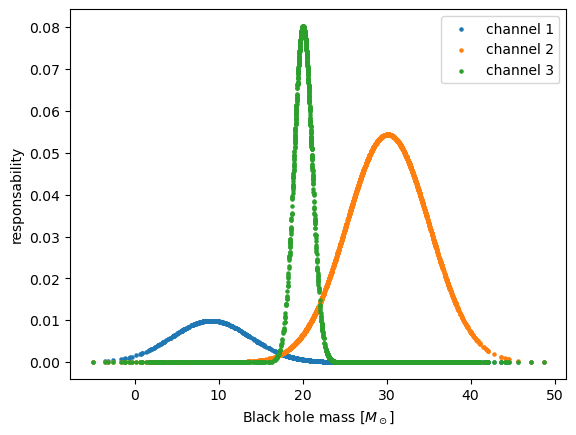

In [62]:
plt.scatter(x, PDF_tot_plot_cluster[:,0], s=5, label="channel 1")
plt.scatter(x,PDF_tot_plot_cluster[:,1], s=5, label="channel 2")
plt.scatter(x, PDF_tot_plot_cluster[:,2], s=5, label ="channel 3")
plt.ylabel("responsability")
plt.xlabel(r"Black hole mass $[M_\odot]$")
plt.legend()